<a href="https://colab.research.google.com/github/Giassinne/Machine_Learning/blob/main/TP1_classification_champignons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning TP1 : Reconnaissance de Champignon

### Import des librairies

In [11]:
import pandas as pd
import numpy as np
import os
from IPython.display import Image, display
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn import ensemble
from sklearn.tree import export_graphviz
# pd.set_option('display.max_rows', None) # Afficher toutes les lignes des dataframes
# pd.set_option('display.max_columns', None) # Afficher toutes les lignes des dataframes

### 1. Preparation des données

1.1 importer et afficher les données dans un DataFrame.

Afficher le nombre de champignons toxiques ou non.

Vérifier qu'il n'y as pas de valeurs nulles

In [16]:
my_dataframe = pd.read_csv('/content/drive/MyDrive/B3_MachineLearning/TP_Classification/champignons.csv', dtype={'id_champignons': int})
my_dataframe




,toxicite,surface-chapeau,ecchymoses,attache-lamelles,taille-lamelles,forme-pied,surface-pied-sur-anneau,couleur-pied-sur-anneau,couleur-voile,type-anneau,population
0,toxique,lisse,oui,libre,étroit,élargissant,lisse,blanc,blanc,pendant,dispersée
1,comestible,lisse,oui,libre,large,élargissant,lisse,blanc,blanc,pendant,nombreuse
2,comestible,lisse,oui,libre,large,élargissant,lisse,blanc,blanc,pendant,nombreuse
3,toxique,écaillée,oui,libre,étroit,élargissant,lisse,blanc,blanc,pendant,dispersée
4,comestible,lisse,non,libre,large,effilé,lisse,blanc,blanc,évasé,abondante
...,...,...,...,...,...,...,...,...,...,...,...
8119,comestible,lisse,non,adhérent,large,élargissant,lisse,orange,orange,pendant,clairsemée
8120,comestible,lisse,non,adhérent,large,élargissant,lisse,orange,brun,pendant,variée
8121,comestible,lisse,non,adhérent,large,élargissant,lisse,orange,orange,pendant,clairsemée
8122,toxique,écaillée,non,libre,étroit,effilé,lisse,blanc,blanc,évasé,variée


In [17]:
print(my_dataframe['toxicite'].value_counts())

print(my_dataframe.isnull().sum())

toxicite
comestible    4208
toxique       3916
Name: count, dtype: int64
toxicite                   0
surface-chapeau            0
ecchymoses                 0
attache-lamelles           0
taille-lamelles            0
forme-pied                 0
surface-pied-sur-anneau    0
couleur-pied-sur-anneau    0
couleur-voile              0
type-anneau                0
population                 0
dtype: int64


1.2 Encoder les données avec une colonne 1/0 par valeur possible.Eviter de générer une matrice "sparse"\
Afficher la taille des données (lignes x colonnes) et les noms de colonnes générées.\
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder

In [26]:

encoded_dataframe = pd.get_dummies(my_dataframe, drop_first=False)

print("Taille des données après encodage (lignes x colonnes) :")
print(encoded_dataframe.shape)

print("\nNoms des colonnes générées :")
print(encoded_dataframe.columns.tolist())

Taille des données après encodage (lignes x colonnes) :
(8124, 42)

Noms des colonnes générées :
['toxicite_comestible', 'toxicite_toxique', 'surface-chapeau_fibreuse', 'surface-chapeau_lisse', 'surface-chapeau_rainurée', 'surface-chapeau_écaillée', 'ecchymoses_non', 'ecchymoses_oui', 'attache-lamelles_adhérent', 'attache-lamelles_libre', 'taille-lamelles_large', 'taille-lamelles_étroit', 'forme-pied_effilé', 'forme-pied_élargissant', 'surface-pied-sur-anneau_fibreuse', 'surface-pied-sur-anneau_lisse', 'surface-pied-sur-anneau_soyeuse', 'surface-pied-sur-anneau_écaillée', 'couleur-pied-sur-anneau_beige', 'couleur-pied-sur-anneau_blanc', 'couleur-pied-sur-anneau_brun', 'couleur-pied-sur-anneau_cannelle', 'couleur-pied-sur-anneau_gris', 'couleur-pied-sur-anneau_jaune', 'couleur-pied-sur-anneau_orange', 'couleur-pied-sur-anneau_rose', 'couleur-pied-sur-anneau_rouge', 'couleur-voile_blanc', 'couleur-voile_brun', 'couleur-voile_jaune', 'couleur-voile_orange', 'type-anneau_aucun', 'type-anne

1.3 Créer un nouveau DataFrame avec les données et les noms de colonne (méthode get_feature_names_out() de OneHotEncoder). Mélanger les données. Afficher le résultat.

In [31]:
encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(my_dataframe)
encoded_columns = encoder.get_feature_names_out(my_dataframe.columns)
encoded_dataframe = pd.DataFrame(encoded_array, columns=encoded_columns)
columns_to_exclude = ['toxicite']
encoded_dataframe = shuffle(encoded_dataframe, random_state=42)


encoded_dataframe.head(), encoded_dataframe.shape



(      toxicite_comestible  toxicite_toxique  surface-chapeau_fibreuse  \
 1971                  1.0               0.0                       1.0   
 6654                  0.0               1.0                       0.0   
 5606                  0.0               1.0                       0.0   
 3332                  1.0               0.0                       0.0   
 6988                  0.0               1.0                       0.0   
 
       surface-chapeau_lisse  surface-chapeau_rainurée  \
 1971                    0.0                       0.0   
 6654                    1.0                       0.0   
 5606                    0.0                       0.0   
 3332                    0.0                       0.0   
 6988                    1.0                       0.0   
 
       surface-chapeau_écaillée  ecchymoses_non  ecchymoses_oui  \
 1971                       0.0             1.0             0.0   
 6654                       0.0             1.0             0.0   
 56

1.4 Creer 4 jeux de données : train features et labels (70%) et dev features et labels (30%).\
Utiliser toxicite_toxique comme label. Ne pas garder de label (toxicite_toxique et toxicite_comestible) dans les features !

In [48]:
labels = encoded_dataframe['toxicite_toxique']
features = encoded_dataframe.drop(['toxicite_toxique', 'toxicite_comestible'], axis=1)

In [47]:
labels = encoded_dataframe['toxicite_toxique']
features = encoded_dataframe.drop(['toxicite_toxique', 'toxicite_comestible'], axis=1)

X_train, X_dev, y_train, y_dev = train_test_split(features, labels, test_size=0.3, random_state=42)

print("Train features shape:", X_train.shape)
print("Train labels shape:", y_train.shape)
print("Dev features shape:", X_dev.shape)
print("Dev labels shape:", y_dev.shape)

print("\nTrain features (preview):")
print(X_train.head())
print("\nTrain labels (preview):")
print(y_train.head())

Train features shape: (5686, 40)
Train labels shape: (5686,)
Dev features shape: (2438, 40)
Dev labels shape: (2438,)

Train features (preview):
      surface-chapeau_fibreuse  surface-chapeau_lisse  \
4238                       1.0                    0.0   
7921                       1.0                    0.0   
3939                       1.0                    0.0   
4512                       1.0                    0.0   
6059                       0.0                    1.0   

      surface-chapeau_rainurée  surface-chapeau_écaillée  ecchymoses_non  \
4238                       0.0                       0.0             1.0   
7921                       0.0                       0.0             1.0   
3939                       0.0                       0.0             1.0   
4512                       0.0                       0.0             1.0   
6059                       0.0                       0.0             1.0   

      ecchymoses_oui  attache-lamelles_adhérent  attach

## 2. Arbre de décision

2.1 Entrainer un arbre de décision sur les données d'apprentissage. Afficher l'arbre obtenu en utilisant plot_tree.

In [49]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

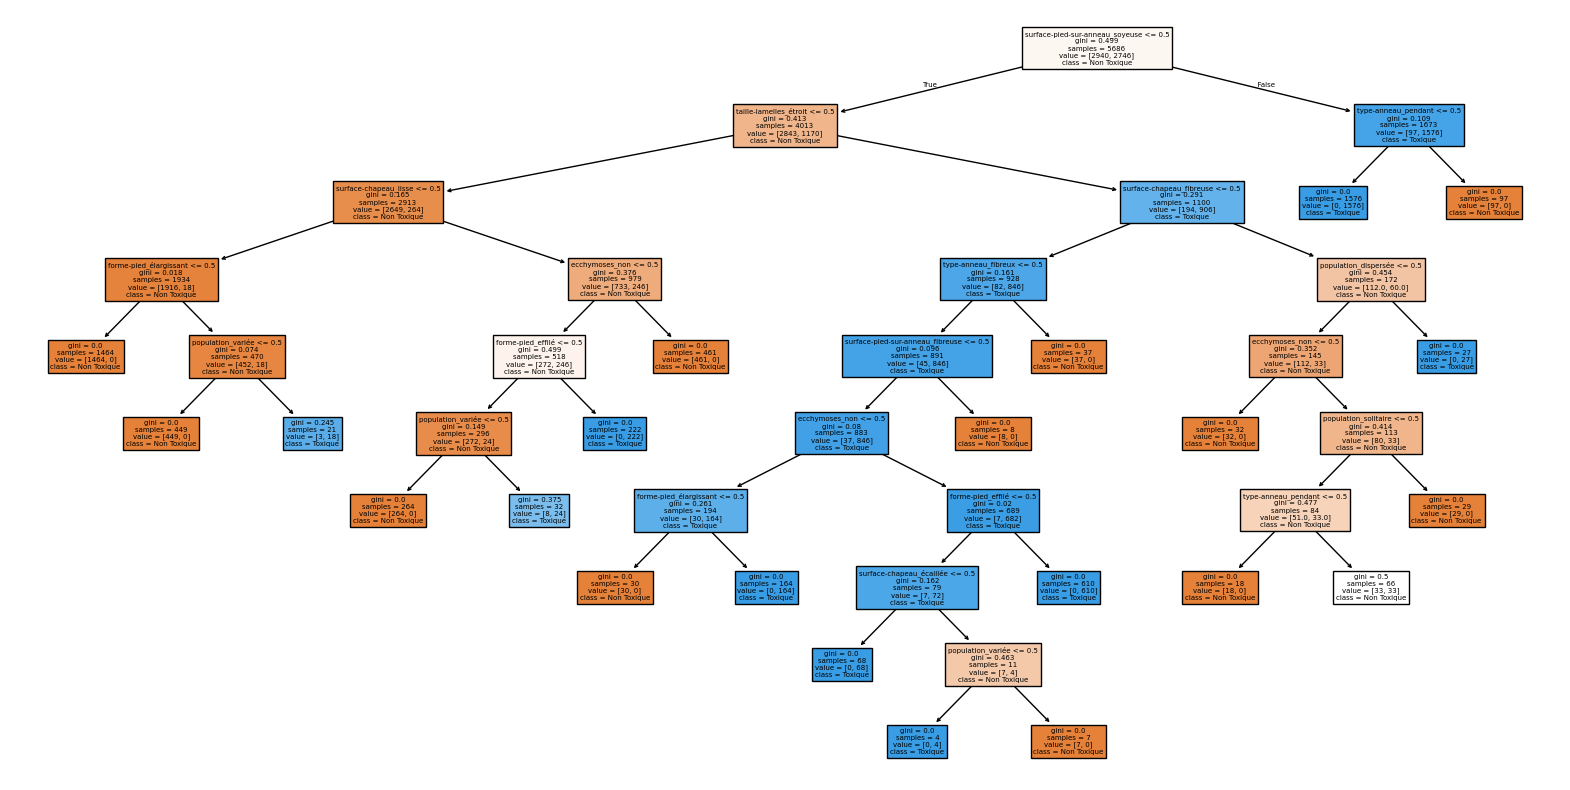

In [50]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Afficher l'arbre
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X_train.columns, class_names=["Non Toxique", "Toxique"], filled=True)
plt.show()

2.2 Afficher l'arbre obtenu en utilisant graphwiz

In [51]:
from sklearn.tree import export_graphviz
from graphviz import Source


In [54]:
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["Non Toxique", "Toxique"],
    filled=True,
    rounded=True,
    special_characters=True
)

In [55]:
graph = Source(dot_data)
graph.render("decision_tree")
graph.view()



'decision_tree.pdf'

2.3 Mesurer la précision du modèle sur les données de dev

In [56]:
from sklearn.metrics import accuracy_score


In [57]:

y_pred = clf.predict(X_dev)
accuracy = accuracy_score(y_dev, y_pred)

print(f"Précision du modèle sur les données de développement : {accuracy:.2f}")


Précision du modèle sur les données de développement : 0.99


## 3. Modèle de forêt

3.1 Réalisez un algorithme de Random Forest sur les données. Utiliser 500 arbres et une profondeur de 6.

In [58]:
from sklearn.ensemble import RandomForestClassifier


In [70]:
random_forest = RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42)
random_forest.fit(X_train, y_train)



RandomForestClassifier(max_depth=6, n_estimators=500, random_state=42)

3.2 Afficher trois arbres au hasard.

In [71]:
from random import randint



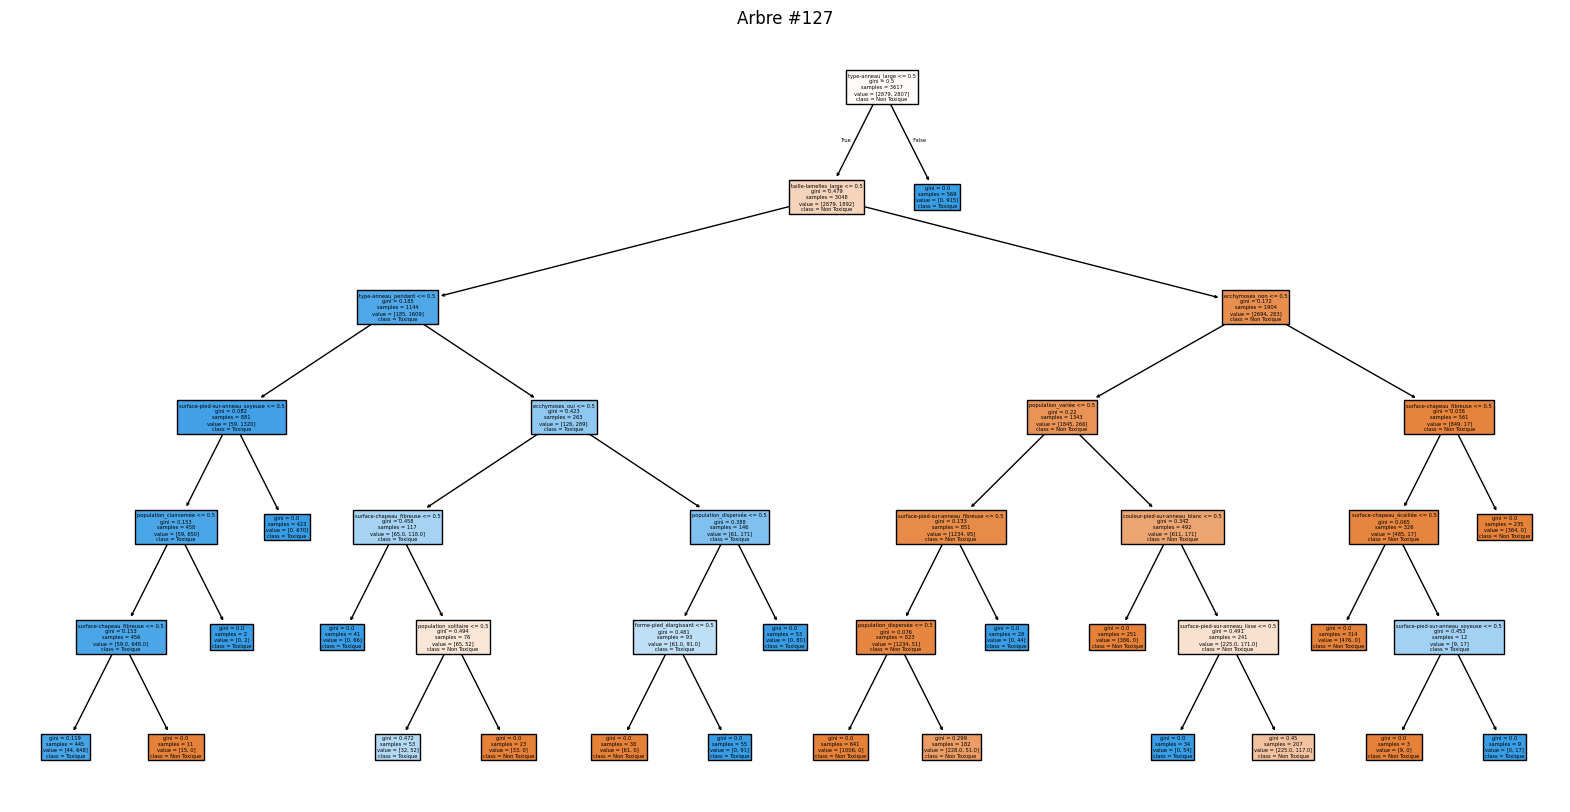

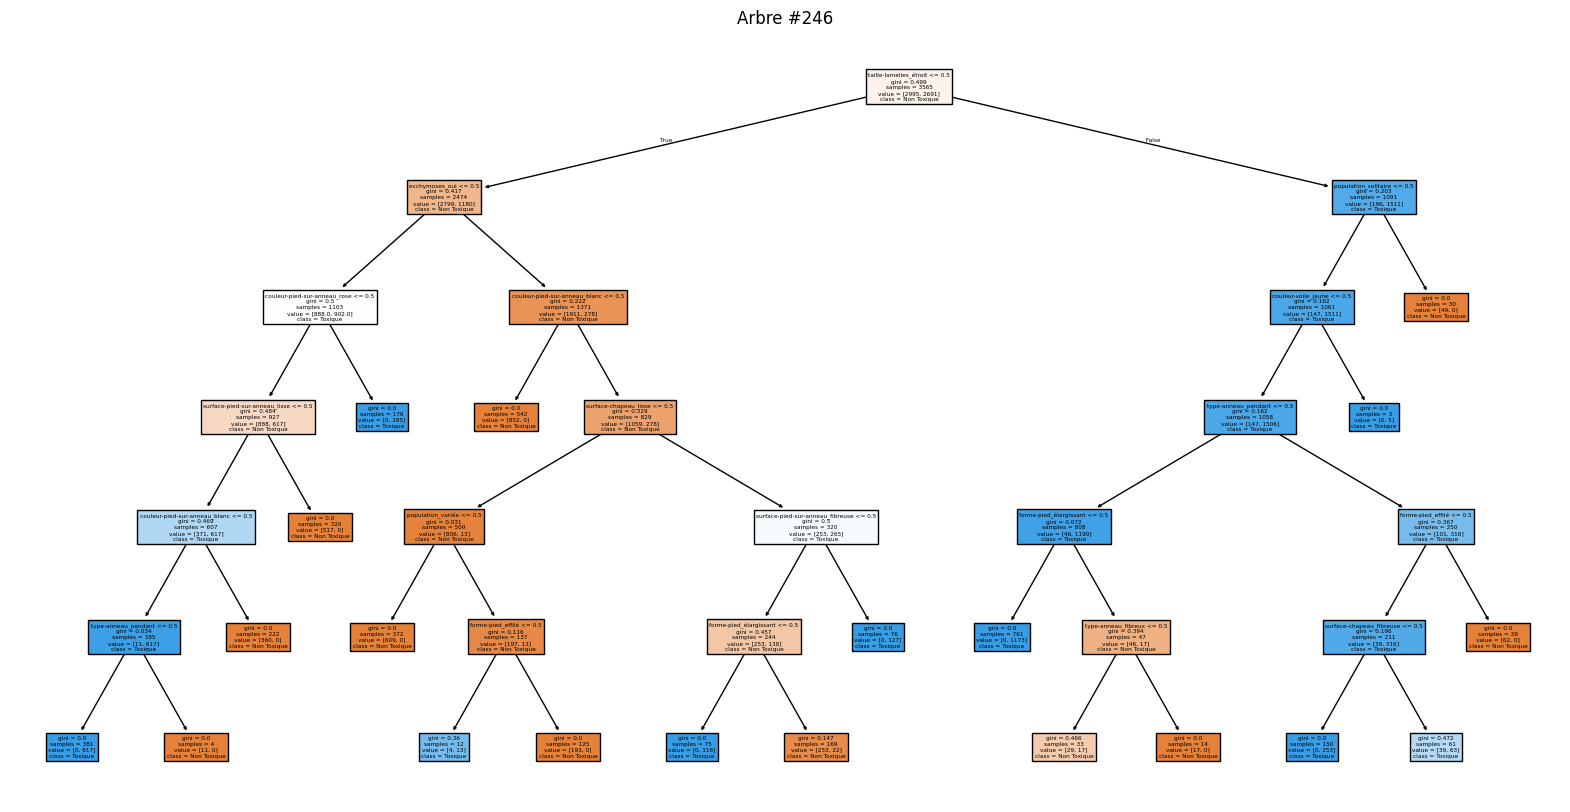

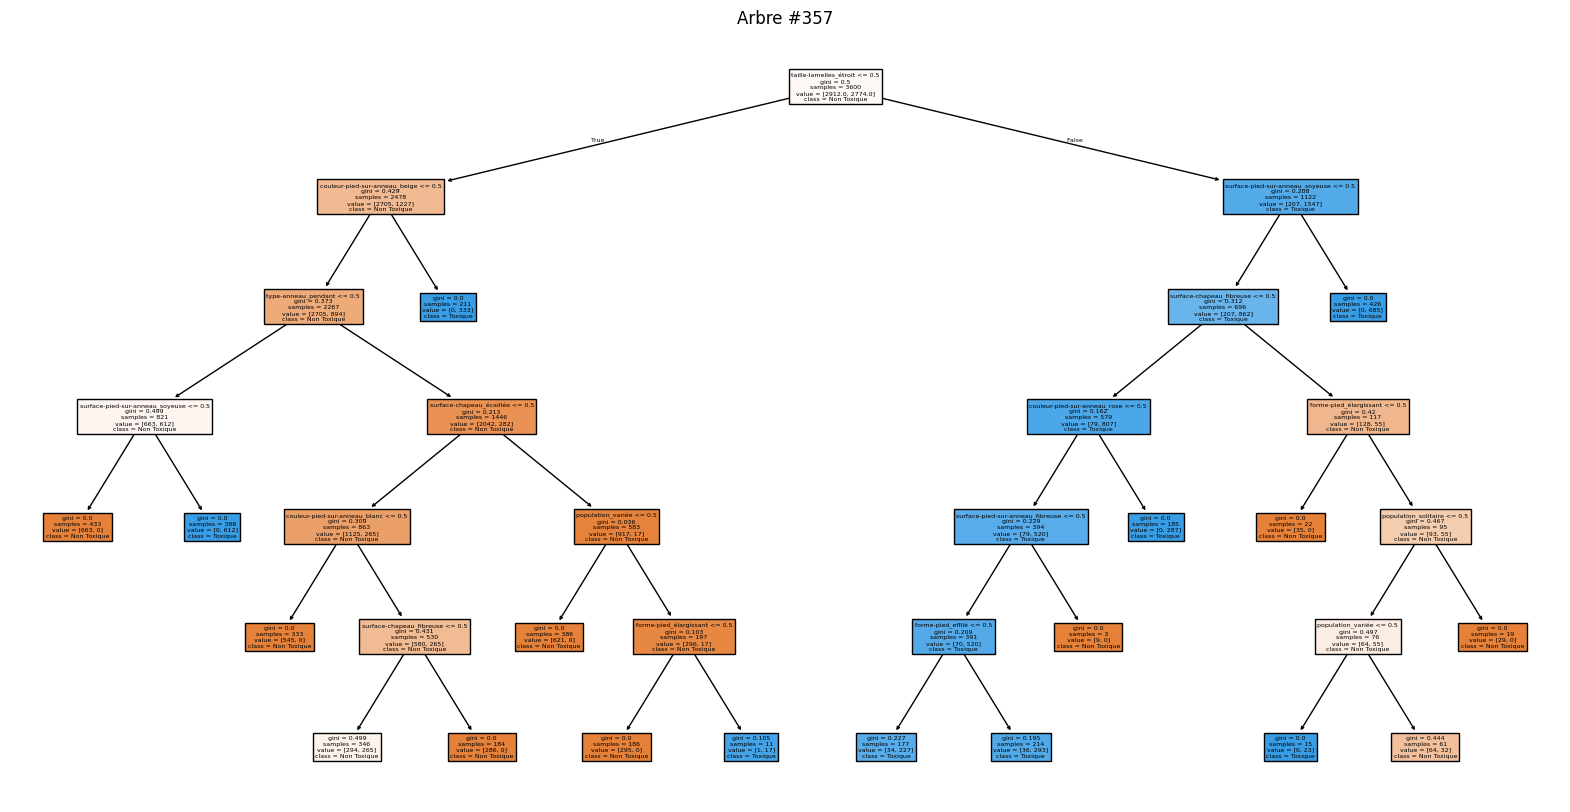

In [74]:
for i, idx in enumerate(indices):
    plt.figure(figsize=(20, 10))
    plot_tree(random_forest.estimators_[idx],
              feature_names=X_train.columns,
              class_names=["Non Toxique", "Toxique"],
              filled=True)
    plt.title(f"Arbre #{idx}")
    plt.show()

3.3 Mesurer la précision du modèle Random Forest sur les données de dev

In [76]:


# Calculer la précision
y_pred_rf = random_forest.predict(X_dev)
accuracy_rf = accuracy_score(y_dev, y_pred_rf)

# Afficher la précision
print(f"Précision du modèle Random Forest sur les données de développement : {accuracy_rf:.2f}")


Précision du modèle Random Forest sur les données de développement : 0.97


## 4. optimisation des paramètres

4.1 En utilisant GridSearchCV, chercher la meilleure combinaison max_depth et n_estimator.

Afficher les paramètre du modèle et a précision obtenue.

Réexécuter un apprentissage avec la meilleure combinaison.


In [ ]:
from sklearn.model_selection import GridSearchCV


4.2 Afficher les paramètres optimaux et la précisions obtenue sur les données dev

4.3 Classer et Afficher les caractéristiques d'importance supérieure à 1%

## 5. Stacking

Essayer différents modèles d'estimateur final

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.ensemble import StackingClassifier


## 6. Gradient Boosting

6. Exécuter un apprentissage de Gradient Boosting avec et sans "Early Stopping" sur le nombre d'estimateurs. Comparer avec le résultat sur les données dev.

## 7. (Optionnel) Recommencer les execices précédents en utilisant les "ordinal encoders". Que remarquez-vous ?